In [31]:
import pandas as pd
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import seaborn as sns
pd.set_option('chained_assignment',None)


In [2]:
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'fraktionslos']

In [22]:
df_interruptions = pd.read_csv('./data/comments.csv')
df_interruptions.head(10)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der W...,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist doch die erste Lesung!,CDU/CSU,<unknown>,DIE LINKE,Dr. Barbara Höll,1991-03-12,11,2
3,3,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
4,4,Gebt erst mal das Vermögen der PDS dem Staat ...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
5,5,Die PDS soll das Vermögen zurückgeben!,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
6,6,Wundert Sie das?,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
7,7,Der muß auch noch reden? Reicht denn nicht ei...,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
8,8,Das sagen Sie!,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
9,9,Wohl wahr!,FDP,Dr. Graf Lambsdorff,FDP,Dr. Wolfgang Weng,1991-03-12,180,8


Einige (wenige) Felder sind leider leer aus den Protokollen geparst worden. Die nehmen wir jetzt heraus.

In [54]:
non_string_entries = df_interruptions['comment_text'].apply(lambda x: not isinstance(x, str))
df_interruptions[non_string_entries]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
12513,12513,NaN,CDU/CSU,<unknown>,SPD,Jan Oostergetelo,1992-06-24,75,8693
16615,16615,NaN,CDU/CSU,Bartholomäus Kalb,CDU/CSU,Manfred Kolbe,1992-11-26,87,11511
40594,40594,NaN,FDP,Ulrich Irmer,GRÜNE,Dr. Helmut Lippelt,1995-09-29,26,30080
45906,45906,NaN,FDP,Dr. Klaus Röhl,SPD,Ursula Burchardt,1996-04-24,38,34213
80506,80506,NaN,CDU/CSU,Norbert Geis,SPD,Hermann Bachmaier,2000-03-23,33,54995
80593,80593,NaN,SPD,Ludwig Stiegler,CDU/CSU,Dr. Norbert Lammert,2000-03-24,58,55017
83273,83273,NaN,FDP,Hans-Michael Goldmann,FDP,Marita Sehn,2000-06-29,33,56237
330343,330343,NaN,FDP,Benjamin Strasser,SPD,Dr. Lars Castellucci,2017-12-13,50,163566
385456,385456,NaN,AfD,Marc Bernhard,AfD,Marc Bernhard,2020-11-26,34,190990
407540,407540,NaN,AfD,Jörn König,AfD,Jörn König,2022-06-23,39,203838


In [55]:
df_interruptions= df_interruptions[~non_string_entries]

In [6]:
texts_per_party = df_interruptions.groupby('comment_party')['comment_text'].apply(lambda x: ' '.join(x))

In [7]:
texts_per_party

comment_party
AfD             Ha, ha, ha! Das ist nicht unser Problem! Ui, d...
CDU/CSU         Das ist doch die  erste Lesung! Gebt erst  mal...
DIE LINKE       So kriegen Sie  die Steuerlüge nicht aus der W...
FDP             Wohl wahr! Verfassungswidrig! Unfug! Wofür  so...
GRÜNE           Das ist Rea  Sie fielen gestern im Plenum! Wah...
SPD             Bravo! Haben Sie vergessen  hinzuschauen? Sind...
fraktionslos    Bei Wechsel  der Verhältnisse! Er ist trotz de...
Name: comment_text, dtype: object

In [15]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\stern\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [16]:
tokenizer = nltk.data.load("tokenizers/punkt/german.pickle")

In [34]:

def get_ngrams(text, n):
    tokens = word_tokenize(text, language = 'german')
    return list(ngrams(tokens, n))

ngrams_data = {}
for party, text in texts_per_party.items():
    print(party)
    unigrams = get_ngrams(text, 1)
    bigrams = get_ngrams(text, 2)
    trigrams = get_ngrams(text, 3)
    
    ngrams_data[party] = {
        'unigrams': Counter(unigrams),
        'bigrams': Counter(bigrams),
        'trigrams': Counter(trigrams)
    }

AfD
CDU/CSU
DIE LINKE
FDP
GRÜNE
SPD
fraktionslos


In [40]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('ichglaubejedenscheiss.de', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
462772,462772,www.ichglaubejedenscheiss.de!,AfD,Martin Reichardt,SPD,Josephine Ortleb,2024-03-15,34,221700


In [42]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Naturschutzzerstörungsfraktion', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
394229,394229,Die Naturschutzzerstörungsfraktion seid ihr!,AfD,Karsten Hilse,GRÜNE,Steffi Lemke,2021-05-20,37,196876


In [45]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Verschwörungstheoretiker', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
312819,312819,Alles Verschwörungstheoretiker!,GRÜNE,Sylvia Kotting-Uhl,SPD,Klaus Barthel,2016-05-11,77,154789
337842,337842,Von anderen Verschwörungstheoretikern!,FDP,Konstantin Kuhle,AfD,Stephan Brandner,2018-06-14,50,167757
347197,347197,Verschwörungstheoretiker!,SPD,<unknown>,AfD,Armin-Paulus Hampel,2018-11-30,51,171932
348183,348183,Die Krise ist ja nicht weg! Verschwörungstheor...,AfD,Leif-Erik Holm,SPD,Metin Hakverdi,2018-12-13,61,172354
354722,354722,Verschwörungstheoretiker!,AfD,Jörg Schneider,FDP,Konstantin Kuhle,2019-04-05,17,175663
374943,374943,Verschwörungstheoretiker!,AfD,Stephan Brandner,CDU/CSU,Philipp Amthor,2020-05-07,91,185103
374995,374995,So ein Quatsch! Verschwörungstheoretiker! Setz...,CDU/CSU,Tino Sorge,AfD,Detlev Spangenberg,2020-05-07,70,185120
377094,377094,Sie laufen ja lieber bei Verschwörungstheoreti...,SPD,Timon Gremmels,AfD,Andreas Bleck,2020-05-29,44,186228
379039,379039,Uns als Verschwörungstheoretiker zu bezeichnen...,DIE LINKE,Evrim Sommer,FDP,Ulrich Lechte,2020-07-03,42,187388
393887,393887,Das sagen alle Verschwörungstheoretiker!,AfD,Elsner von Gronow,SPD,Dr. Karl-Heinz Brunner,2021-05-07,40,196557


In [46]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Landschaftsverschandelung', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
381621,381621,Landschaftsverschandelung ist das!,AfD,Dr. Götz Frömming,SPD,Yasmin Fahimi,2020-10-01,45,188708


In [49]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*\.de.*|.*\.com.*|www\.', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
325556,325556,Ich empfehle www.linksfraktion.de !,DIE LINKE,Matthias W. Birkwald,SPD,Mechthild Rawert,2017-03-31,57,161180
462772,462772,www.ichglaubejedenscheiss.de!,AfD,Martin Reichardt,SPD,Josephine Ortleb,2024-03-15,34,221700
463355,463355,chefkoch.de!,AfD,Beatrix von Storch,SPD,Dr. Jens Zimmermann,2024-03-21,51,221980
463379,463379,chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,221987
463380,463380,Für chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,221987
463381,463381,chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,221987


In [50]:

for party, ngram_counts in ngrams_data.items():
    print(f"Partei: {party}")
    print(f"Häufigste unigramme:{ ngram_counts['unigrams'].most_common(10)}")
    print(f"Häufigste bigramme: {ngram_counts['bigrams'].most_common(10)}")
    print(f"Häufigste trigramme: {ngram_counts['trigrams'].most_common(10)}")
    print()

Partei: AfD
Häufigste unigramme:[(('!',), 33654), (('Sie',), 8531), ((',',), 6733), (('Das',), 5536), (('?',), 4637), (('ist',), 4540), (('nicht',), 4000), (('die',), 3505), (('das',), 2946), (('doch',), 2784)]
Häufigste bigramme: [(('!', 'Das'), 4818), (('Das', 'ist'), 2263), (('!', 'Sie'), 2234), (('!', 'Die'), 1277), (('nicht', '!'), 1201), (('!', 'Ja'), 1016), (('!', 'Was'), 836), (('Ja', ','), 791), (('!', 'Wir'), 719), ((',', 'Herr'), 716)]
Häufigste trigramme: [(('!', 'Das', 'ist'), 1964), (('!', 'Ja', ','), 694), (('!', 'Sie', 'haben'), 514), (('!', 'Hört', '!'), 426), (('Das', 'ist', 'doch'), 393), (('!', 'Genau', '!'), 370), (('!', 'Ja', '!'), 307), (('!', 'Sie', 'sind'), 279), (('?', 'Das', 'ist'), 252), (('!', 'Das', 'war'), 249)]

Partei: CDU/CSU
Häufigste unigramme:[(('!',), 135905), (('Sie',), 27237), (('Das',), 26362), (('ist',), 24485), ((',',), 23828), (('nicht',), 17841), (('?',), 17677), (('die',), 13045), (('das',), 12181), (('doch',), 12041)]
Häufigste bigramme: [

Anscheinend ist das '!' sehr hoch im Kurs. Wie viel Prozent der Unterbrechungen enthalten denn ein Ausrufezeichen? 

In [ ]:
percentage_excl_marks = df_interruptions['comment_text'].apply(lambda x:'!' in x).sum()/len(df_interruptions)*100
print(f"{percentage_excl_marks:.2f} %")

86.40 %


Die Kommentatoren wollen sich anscheinend Ausdruck verleihen. Sonst würden sie ja niemanden unterbrechen...

# Wordclouds

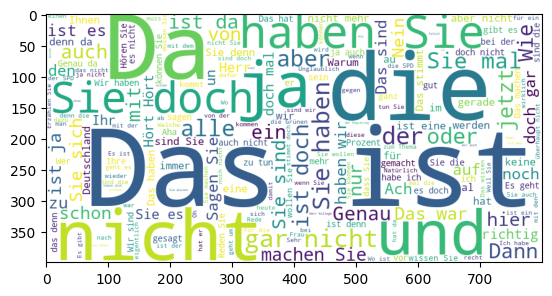

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texts_per_party['AfD'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Jetzt noch mit Stopwords, damit die Ansicht aussagekräftiger wird...

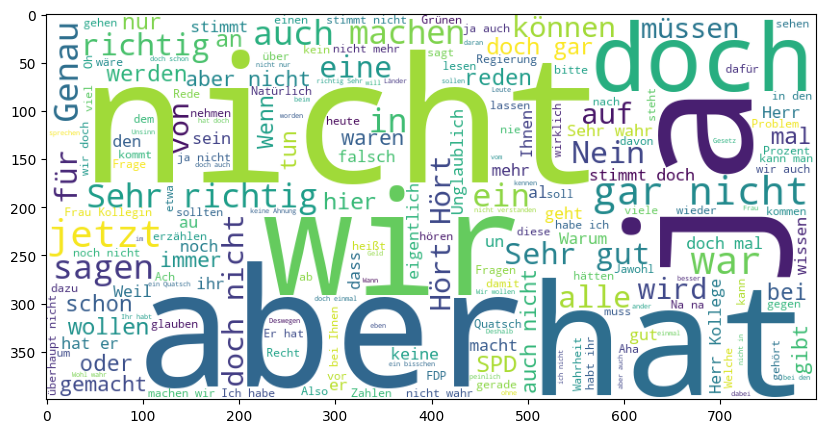

In [9]:
stopwords = ['Da', 'Sie', 'die', 'Das', 'ist', 'und', 'Dann', 'Wer', 'Wo', 'mit', 'gesagt', 'Was', 'sind', 'denn', 'haben', 'e', 'zu', 'sich', 'Ihre', 'der', 'es', 'So', 'Wie']
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(texts_per_party['CDU/CSU'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Die Wortfolge Hört Hört ist wohl ziemlich beliebt...

In [56]:
df_hoert_hoert = df_interruptions[df_interruptions['comment_text'].apply(lambda x: bool(re.search('hört.* hört.*', x, flags= re.UNICODE|re.IGNORECASE)))]
df_hoert_hoert.head(5)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
341,341,Hört! Hört!,SPD,<unknown>,SPD,Ingrid Matthäus-Maier,1991-04-17,48,705
413,413,Hört! Hört!,CDU/CSU,Arnulf Kriedner,CDU/CSU,Dr. Gero Pfennig,1991-04-17,36,718
448,448,Hört! Hört!,FDP,<unknown>,CDU/CSU,Dr. Angela Merkel,1991-04-18,81,742
494,494,Hört! Hört! Da wer,SPD,Dr. Uwe Küster,CDU/CSU,Susanne Rahardt-Vahldieck,1991-04-18,65,757
534,534,Hört! Hört!,CDU/CSU,Peter Kittelmann,CDU/CSU,Horst Eylmann,1991-04-18,45,802


In [57]:
df_hoert_hoert.loc[:,'year'] = df_hoert_hoert['date'].apply(lambda x: x[:4]) 
df_hoert_hoert = df_hoert_hoert.groupby('year').count()['date'].reset_index()
df_hoert_hoert.head(5)

,year,date
0,1991,87
1,1992,61
2,1993,82
3,1994,73
4,1995,77


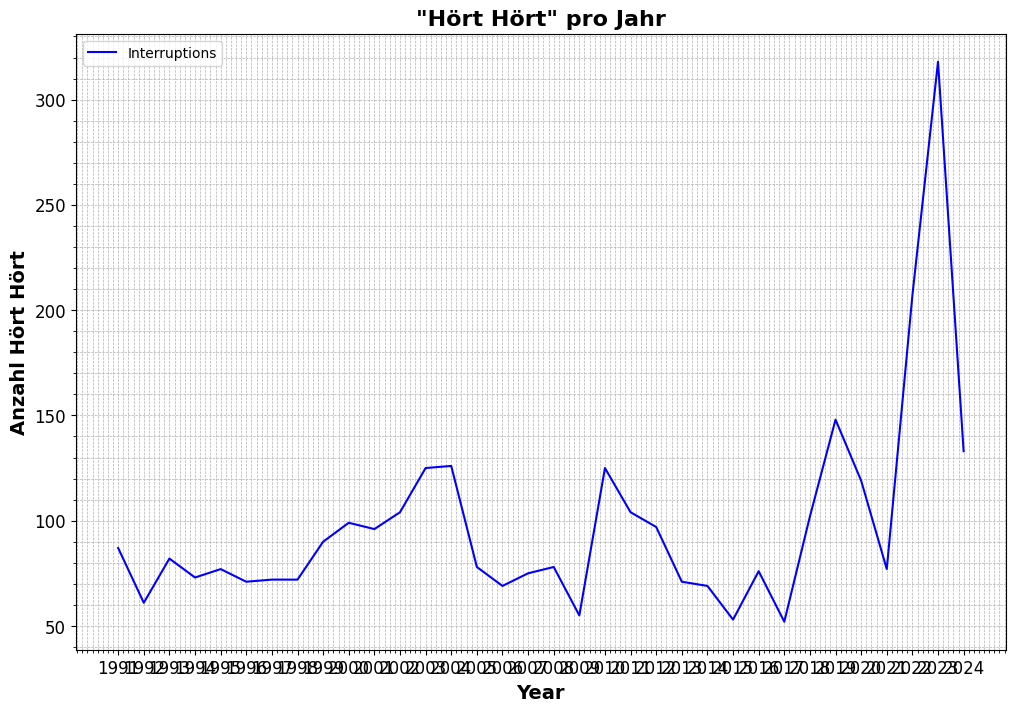

In [62]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=df_hoert_hoert, x='year', y='date', label='Interruptions', color='blue')

plt.xlabel('Year', fontsize=14, weight='bold')
plt.ylabel('Anzahl Hört Hört', fontsize=14, weight='bold')
plt.title('"Hört Hört" pro Jahr', fontsize=16, weight='bold')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', labelsize=12)
#plt.tick_params(axis='both', which='minor', labelsize=10)

plt.show()